<a href="https://colab.research.google.com/github/Sunidhi-Gautam/FL_Implementation/blob/main/plain_fl_fedavg_ft__tomato_corn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================================
# IMPORTS
# ============================================================

import os
import copy
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
# ============================================================
# CHECKPOINT DIRECTORY (Google Drive)
# ============================================================

CHECKPOINT_DIR = "/content/drive/MyDrive/plain_federated_multicrop_training"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("Checkpoint directory:", CHECKPOINT_DIR)

Checkpoint directory: /content/drive/MyDrive/plain_federated_multicrop_training


In [ ]:
import random

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [ ]:
# ============================================================
# INSTALL + DOWNLOAD DATASET
# ============================================================

# Install Kaggle
!pip install -q kaggle

from google.colab import files
files.upload()   # Upload kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [ ]:
# Download Tomato Datasets

!kaggle datasets download -d ashishmotwani/tomato
!kaggle datasets download -d kaustubhb999/tomatoleaf
!kaggle datasets download -d luisolazo/tomato-diseases

# Extract Datasets

!unzip -q tomato.zip -d tomato_A
!unzip -q tomatoleaf.zip -d tomato_B
!unzip -q tomato-diseases.zip -d tomato_unseen

print("Tomato Datasets extracted.")

Dataset URL: https://www.kaggle.com/datasets/ashishmotwani/tomato
License(s): copyright-authors
100% 1.37G/1.37G [00:15<00:00, 93.1MB/s]

Dataset URL: https://www.kaggle.com/datasets/kaustubhb999/tomatoleaf
License(s): CC0-1.0
100% 179M/179M [00:00<00:00, 217MB/s]

Dataset URL: https://www.kaggle.com/datasets/luisolazo/tomato-diseases
License(s): CC0-1.0
100% 411M/411M [00:03<00:00, 122MB/s]

Tomato Datasets extracted.


In [ ]:
# Download Corn Datasets

!kaggle datasets download -d smaranjitghose/corn-or-maize-leaf-disease-dataset
!kaggle datasets download -d nafishamoin/new-bangladeshi-crop-disease
!kaggle datasets download -d karagwaanntreasure/plant-disease-detection

# Extract Datasets

!unzip -qo corn-or-maize-leaf-disease-dataset.zip -d corn_A
!unzip -qo new-bangladeshi-crop-disease.zip -d corn_B
!unzip -qo plant-disease-detection.zip -d corn_unseen

print("Corn datasets downloaded and extracted successfully.")

Dataset URL: https://www.kaggle.com/datasets/smaranjitghose/corn-or-maize-leaf-disease-dataset
License(s): copyright-authors
100% 161M/161M [00:01<00:00, 114MB/s] 

Dataset URL: https://www.kaggle.com/datasets/nafishamoin/new-bangladeshi-crop-disease
License(s): copyright-authors
100% 2.35G/2.35G [00:31<00:00, 80.7MB/s]

Dataset URL: https://www.kaggle.com/datasets/karagwaanntreasure/plant-disease-detection
License(s): MIT
100% 534M/534M [00:04<00:00, 137MB/s]

Corn datasets downloaded and extracted successfully.


In [ ]:
def show_tree(path, depth=6):
    for root, dirs, files in os.walk(path):
        level = root.replace(path, '').count(os.sep)
        if level < depth:
            print("  " * level + os.path.basename(root))

print("=== CORN_A STRUCTURE ===")
show_tree("corn_A", depth=6)

print("\n=== CORN_B STRUCTURE ===")
show_tree("corn_B", depth=6)

print("\n=== CORN_UNSEEN STRUCTURE ===")
show_tree("corn_unseen", depth=6)

=== CORN_A STRUCTURE ===
corn_A
  data
    Healthy
    Common_Rust
    Gray_Leaf_Spot
    Blight

=== CORN_B STRUCTURE ===
corn_B
  Invalid
    Invalid
  BangladeshiCrops
    BangladeshiCrops
      Crop___Disease
        Rice
          Rice___Leaf_Blast
          Rice___Neck_Blast
          Rice___Healthy
          Rice___Brown_Spot
        Potato
          Potato___Early_Blight
          Potato___Healthy
          Potato___Late_Blight
        Corn
          Corn___Northern_Leaf_Blight
          Corn___Gray_Leaf_Spot
          Corn___Healthy
          Corn___Common_Rust
        Wheat
          Wheat___Brown_Rust
          Wheat___Yellow_Rust
          Wheat___Healthy

=== CORN_UNSEEN STRUCTURE ===
corn_unseen
  Dataset
    Tomato__Tomato_mosaic_virus
    Apple___Cedar_apple_rust
    Pepper__bell___healthy
    Tomato_Spider_mites_Two_spotted_spider_mite
    Tomato_Early_blight
    Potato___Late_blight
    Tomato_Late_blight
    Corn_(maize)___Northern_Leaf_Blight
    Corn_(maize)___heal

In [ ]:
import os
import shutil

# 1. Keep only CORN in corn_B

root = "corn_B/BangladeshiCrops/BangladeshiCrops/Crop___Disease"

for folder in os.listdir(root):
    if folder != "Corn":
        shutil.rmtree(os.path.join(root, folder), ignore_errors=True)

print("Removed non-corn crops from corn_B")


# 2. Keep only corn folders in corn_unseen

unseen_root = "corn_unseen/Dataset"

for folder in os.listdir(unseen_root):

    if not folder.lower().startswith("corn"):
        shutil.rmtree(os.path.join(unseen_root, folder), ignore_errors=True)

print("Removed non-corn crops from corn_unseen")


Removed non-corn crops from corn_B
Removed non-corn crops from corn_unseen


In [ ]:
def show_tree(path, depth=6):
    for root, dirs, files in os.walk(path):
        level = root.replace(path, '').count(os.sep)
        if level < depth:
            print("  " * level + os.path.basename(root))

print("=== CORN_A STRUCTURE ===")
show_tree("corn_A", depth=6)

print("\n=== CORN_B STRUCTURE ===")
show_tree("corn_B", depth=6)

print("\n=== CORN_UNSEEN STRUCTURE ===")
show_tree("corn_unseen", depth=6)

=== CORN_A STRUCTURE ===
corn_A
  data
    Healthy
    Common_Rust
    Gray_Leaf_Spot
    Blight

=== CORN_B STRUCTURE ===
corn_B
  Invalid
    Invalid
  BangladeshiCrops
    BangladeshiCrops
      Crop___Disease
        Corn
          Corn___Northern_Leaf_Blight
          Corn___Gray_Leaf_Spot
          Corn___Healthy
          Corn___Common_Rust

=== CORN_UNSEEN STRUCTURE ===
corn_unseen
  Dataset
    Corn_(maize)___Northern_Leaf_Blight
    Corn_(maize)___healthy
    Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
    Corn_(maize)___Common_rust_


In [ ]:
import os
import shutil


# Remove invalid folder

invalid_path = "corn_B/Invalid"
if os.path.exists(invalid_path):
    shutil.rmtree(invalid_path)

print("Removed invalid folder")


# Label mapping

label_map = {

    # healthy
    "Healthy": "corn_healthy",
    "Corn___Healthy": "corn_healthy",
    "Corn_(maize)___healthy": "corn_healthy",

    # blight
    "Blight": "blight",
    "Corn___Northern_Leaf_Blight": "blight",
    "Corn_(maize)___Northern_Leaf_Blight": "blight",

    # rust
    "Common_Rust": "common_rust",
    "Corn___Common_Rust": "common_rust",
    "Corn_(maize)___Common_rust_": "common_rust",

    # gray leaf spot
    "Gray_Leaf_Spot": "gray_leaf_spot",
    "Corn___Gray_Leaf_Spot": "gray_leaf_spot",
    "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot": "gray_leaf_spot"
}



# Safe file move (handles duplicates)

def safe_move(src, dst_folder):

    filename = os.path.basename(src)
    dst = os.path.join(dst_folder, filename)

    name, ext = os.path.splitext(filename)
    counter = 1

    while os.path.exists(dst):
        dst = os.path.join(dst_folder, f"{name}_{counter}{ext}")
        counter += 1

    shutil.move(src, dst)

# Function to rename folders

def rename_folders(root):

    for folder in os.listdir(root):

        old_path = os.path.join(root, folder)

        if not os.path.isdir(old_path):
            continue

        if folder in label_map:

            new_name = label_map[folder]
            new_path = os.path.join(root, new_name)

            if not os.path.exists(new_path):
                os.rename(old_path, new_path)

            else:
                # merge folders safely
                for f in os.listdir(old_path):
                    src_file = os.path.join(old_path, f)
                    safe_move(src_file, new_path)

                shutil.rmtree(old_path)

# Apply renaming

rename_folders("corn_A/data")

rename_folders("corn_B/BangladeshiCrops/BangladeshiCrops/Crop___Disease/Corn")

rename_folders("corn_unseen/Dataset")

print("Labels standardized across datasets")


Removed invalid folder
Labels standardized across datasets


In [ ]:
# ============================================================
# Folder Structure Inspection
# ============================================================

def show_tree(path, depth=3):
    for root, dirs, files in os.walk(path):
        level = root.replace(path, '').count(os.sep)
        if level < depth:
            print("  " * level + os.path.basename(root))

# ---------------- TOMATO DATASETS ----------------

print("=== TOMATO DATASET A (Train Domain) ===")
show_tree("tomato_A")

print("\n=== TOMATO DATASET B (Train Domain) ===")
show_tree("tomato_B", depth=4)

print("\n=== TOMATO DATASET C (UNSEEN DOMAIN) ===")
show_tree("tomato_unseen")

# ---------------- CORN DATASETS ----------------

print("\n=== CORN DATASET A (Train Domain) ===")
show_tree("corn_A", depth = 6)

print("\n=== CORN DATASET B (Train Domain) ===")
show_tree("corn_B/BangladeshiCrops/BangladeshiCrops/Crop___Disease/Corn")

print("\n=== CORN DATASET C (UNSEEN DOMAIN) ===")
show_tree("corn_unseen", depth = 6)

=== TOMATO DATASET A (Train Domain) ===
tomato_A
  valid
    healthy
    Tomato_Yellow_Leaf_Curl_Virus
    Early_blight
    Target_Spot
    Leaf_Mold
    Spider_mites Two-spotted_spider_mite
    Late_blight
    Septoria_leaf_spot
    Bacterial_spot
    powdery_mildew
    Tomato_mosaic_virus
  train
    healthy
    Tomato_Yellow_Leaf_Curl_Virus
    Early_blight
    Target_Spot
    Leaf_Mold
    Spider_mites Two-spotted_spider_mite
    Late_blight
    Septoria_leaf_spot
    Bacterial_spot
    powdery_mildew
    Tomato_mosaic_virus

=== TOMATO DATASET B (Train Domain) ===
tomato_B
  tomato
    val
      Tomato___Bacterial_spot
      Tomato___Tomato_Yellow_Leaf_Curl_Virus
      Tomato___Target_Spot
      Tomato___healthy
      Tomato___Tomato_mosaic_virus
      Tomato___Septoria_leaf_spot
      Tomato___Spider_mites Two-spotted_spider_mite
      Tomato___Leaf_Mold
      Tomato___Early_blight
      Tomato___Late_blight
    train
      Tomato___Bacterial_spot
      Tomato___Tomato_Yellow_Lea

Dataset Preprocessing

In [ ]:
# ============================================================
# Delete the extra class
# ============================================================

import shutil

paths_to_delete = [
    "tomato_A/train/powdery_mildew",
    "tomato_A/valid/powdery_mildew"
]

for p in paths_to_delete:
    if os.path.exists(p):
        shutil.rmtree(p)
        print(f"Deleted: {p}")

Deleted: tomato_A/train/powdery_mildew
Deleted: tomato_A/valid/powdery_mildew


In [ ]:
# ============================================================
# Inspect folder structures again
# ============================================================

def show_tree(path, depth=3):
    for root, dirs, files in os.walk(path):
        level = root.replace(path, '').count(os.sep)
        if level < depth:
            print("  " * level + os.path.basename(root))

print("=== Dataset A ===")
show_tree("tomato_A")

print("\n=== Dataset B ===")
show_tree("tomato_B", depth=4)

print("\n=== Unseen Dataset ===")
show_tree("tomato_unseen")

=== Dataset A ===
tomato_A
  valid
    healthy
    Tomato_Yellow_Leaf_Curl_Virus
    Early_blight
    Target_Spot
    Leaf_Mold
    Spider_mites Two-spotted_spider_mite
    Late_blight
    Septoria_leaf_spot
    Bacterial_spot
    Tomato_mosaic_virus
  train
    healthy
    Tomato_Yellow_Leaf_Curl_Virus
    Early_blight
    Target_Spot
    Leaf_Mold
    Spider_mites Two-spotted_spider_mite
    Late_blight
    Septoria_leaf_spot
    Bacterial_spot
    Tomato_mosaic_virus

=== Dataset B ===
tomato_B
  tomato
    val
      Tomato___Bacterial_spot
      Tomato___Tomato_Yellow_Leaf_Curl_Virus
      Tomato___Target_Spot
      Tomato___healthy
      Tomato___Tomato_mosaic_virus
      Tomato___Septoria_leaf_spot
      Tomato___Spider_mites Two-spotted_spider_mite
      Tomato___Leaf_Mold
      Tomato___Early_blight
      Tomato___Late_blight
    train
      Tomato___Bacterial_spot
      Tomato___Tomato_Yellow_Leaf_Curl_Virus
      Tomato___Target_Spot
      Tomato___healthy
      Tomato___Toma

In [ ]:
# ============================================================
# Dataset Scanning for any missing / corrupt values
# ============================================================

from PIL import Image
import pandas as pd
from tqdm import tqdm

def scan_dataset(root_dir, dataset_name):
    records = []
    broken = []

    for root, dirs, files in os.walk(root_dir):
      dirs.sort()
      files.sort()
      for file in files:
          if file.lower().endswith((".jpg", ".jpeg", ".png")):
              path = os.path.join(root, file)
              label = os.path.basename(root)
              try:
                  with Image.open(path) as img:
                      img.verify()
                  records.append({
                      "dataset": dataset_name,
                      "path": path,
                      "raw_label": label
                  })
              except:
                  broken.append(path)

    print(f"{dataset_name}: {len(records)} valid images")
    print(f"{dataset_name}: {len(broken)} broken images")

    return pd.DataFrame(records)

df_A = scan_dataset("tomato_A", "tomato_A")
df_B = scan_dataset("tomato_B/tomato", "tomato_B")
df_C = scan_dataset("tomato_unseen", "tomato_C")

df_corn_A = scan_dataset("corn_A", "corn_A")
df_corn_B = scan_dataset(
    "corn_B/BangladeshiCrops/BangladeshiCrops/Crop___Disease/Corn",
    "corn_B"
)

df_corn_C = scan_dataset("corn_unseen/Dataset", "corn_C")

df_raw = pd.concat([
    df_A, df_B, df_C,
    df_corn_A, df_corn_B, df_corn_C
]).reset_index(drop=True)

print("Total images:", len(df_raw))

tomato_A: 31278 valid images
tomato_A: 0 broken images
tomato_B: 11000 valid images
tomato_B: 0 broken images
tomato_C: 22193 valid images
tomato_C: 0 broken images
corn_A: 4188 valid images
corn_A: 0 broken images
corn_B: 3852 valid images
corn_B: 0 broken images
corn_C: 7316 valid images
corn_C: 0 broken images
Total images: 79827


Label Harmonization

In [ ]:
# ============================================================
# Canonical Labels
# ============================================================

tomato_labels = [
    "bacterial_spot",
    "early_blight",
    "late_blight",
    "leaf_mold",
    "mosaic_virus",
    "septoria_leaf_spot",
    "spider_mites",
    "target_spot",
    "yellow_leaf_curl_virus",
    "tomato_healthy"
]

corn_labels = [
    "blight",
    "common_rust",
    "gray_leaf_spot",
    "corn_healthy"
]

canonical_labels = tomato_labels + corn_labels
label_to_id = {label: idx for idx, label in enumerate(canonical_labels)}
id_to_label = {idx: label for idx, label in enumerate(canonical_labels)}

In [ ]:
print("Total classes:", len(canonical_labels))
print(label_to_id)

Total classes: 14
{'bacterial_spot': 0, 'early_blight': 1, 'late_blight': 2, 'leaf_mold': 3, 'mosaic_virus': 4, 'septoria_leaf_spot': 5, 'spider_mites': 6, 'target_spot': 7, 'yellow_leaf_curl_virus': 8, 'tomato_healthy': 9, 'blight': 10, 'common_rust': 11, 'gray_leaf_spot': 12, 'corn_healthy': 13}


In [ ]:
# ============================================================
# Dataset-Specific Label Mapping
# ============================================================

mapping_tomato_A = {
    "Bacterial_spot": "bacterial_spot",
    "Early_blight": "early_blight",
    "Late_blight": "late_blight",
    "Leaf_Mold": "leaf_mold",
    "Tomato_mosaic_virus": "mosaic_virus",
    "Septoria_leaf_spot": "septoria_leaf_spot",
    "Spider_mites Two-spotted_spider_mite": "spider_mites",
    "Target_Spot": "target_spot",
    "Tomato_Yellow_Leaf_Curl_Virus": "yellow_leaf_curl_virus",
    "healthy": "tomato_healthy"
}

mapping_tomato_B = {
    "Tomato___Bacterial_spot": "bacterial_spot",
    "Tomato___Early_blight": "early_blight",
    "Tomato___Late_blight": "late_blight",
    "Tomato___Leaf_Mold": "leaf_mold",
    "Tomato___Tomato_mosaic_virus": "mosaic_virus",
    "Tomato___Septoria_leaf_spot": "septoria_leaf_spot",
    "Tomato___Spider_mites Two-spotted_spider_mite": "spider_mites",
    "Tomato___Target_Spot": "target_spot",
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus": "yellow_leaf_curl_virus",
    "Tomato___healthy": "tomato_healthy"
}

mapping_tomato_C = {
    "bacterial_spot": "bacterial_spot",
    "early_blight": "early_blight",
    "late_blight": "late_blight",
    "leaf_mold": "leaf_mold",
    "mosaic_virus": "mosaic_virus",
    "septoria_leaf_spot": "septoria_leaf_spot",
    "twospotted_spider_mite": "spider_mites",
    "target_spot": "target_spot",
    "yellow_leaf_curl_virus": "yellow_leaf_curl_virus",
    "healthy": "tomato_healthy"
}

mapping_corn_A = {
    "blight": "blight",
    "common_rust": "common_rust",
    "gray_leaf_spot": "gray_leaf_spot",
    "corn_healthy": "corn_healthy"
}

mapping_corn_B = mapping_corn_A.copy()

mapping_corn_C = mapping_corn_A.copy()

In [ ]:
# ============================================================
# Apply Harmonization
# ============================================================

def harmonize(row):

    dataset = row["dataset"]
    label = row["raw_label"]

    try:

        if dataset == "tomato_A":
            return mapping_tomato_A[label]

        elif dataset == "tomato_B":
            return mapping_tomato_B[label]

        elif dataset == "tomato_C":
            return mapping_tomato_C[label]

        elif dataset == "corn_A":
            return mapping_corn_A[label]

        elif dataset == "corn_B":
            return mapping_corn_B[label]

        elif dataset == "corn_C":
            return mapping_corn_C[label]

    except KeyError:
        print(f"⚠ Missing label mapping | Dataset: {dataset} | Label: {label}")
        return None

df_raw['canonical_label'] = df_raw.apply(harmonize, axis=1)

df_raw = df_raw.dropna(subset=["canonical_label"])

df_raw['class_id'] = df_raw['canonical_label'].map(label_to_id)

In [ ]:
print("Unique canonical labels:")
print(sorted(df_raw["canonical_label"].unique()))

print("\nTotal classes:", df_raw["canonical_label"].nunique())

Unique canonical labels:
['bacterial_spot', 'blight', 'common_rust', 'corn_healthy', 'early_blight', 'gray_leaf_spot', 'late_blight', 'leaf_mold', 'mosaic_virus', 'septoria_leaf_spot', 'spider_mites', 'target_spot', 'tomato_healthy', 'yellow_leaf_curl_virus']

Total classes: 14


In [ ]:
print("Remaining images:", len(df_raw))

Remaining images: 79827


Client Mapping

In [ ]:
client_mapping = {
    'tomato_A': 0,
    'tomato_B': 1,
    'corn_A'  : 2,
    'corn_B'  : 3,
    'tomato_C': 4,   # unseen domain
    'corn_C'  : 5    # unseen domain
}

df_raw['domain'] = df_raw['dataset'].map(client_mapping)
print(df_raw.groupby("dataset").size())
print(df_raw.groupby("domain").size())

dataset
corn_A       4188
corn_B       3852
corn_C       7316
tomato_A    31278
tomato_B    11000
tomato_C    22193
dtype: int64
domain
0    31278
1    11000
2     4188
3     3852
4    22193
5     7316
dtype: int64


In [ ]:
# ============================================================
# FINAL DATAFRAME FOR TRAINING
# ============================================================

df_all = df_raw.copy()

labels = canonical_labels
NUM_CLASSES = len(labels)

print("Total images:", len(df_all))
print("Number of classes:", NUM_CLASSES)

Total images: 79827
Number of classes: 14


In [ ]:
print(df_all["canonical_label"].value_counts())

canonical_label
yellow_leaf_curl_virus    7676
late_blight               7542
tomato_healthy            7283
early_blight              6819
bacterial_spot            6781
septoria_leaf_spot        6499
leaf_mold                 6497
mosaic_virus              5478
spider_mites              4958
target_spot               4938
common_rust               4405
corn_healthy              4183
blight                    4039
gray_leaf_spot            2729
Name: count, dtype: int64


Domain Distribution per Dataset

In [ ]:
print("Domain distribution per dataset:")
print(df_raw.groupby(['dataset', 'domain']).size())

print("\nSample dataframe with domain labels:")
df_raw.head()

Domain distribution per dataset:
dataset   domain
corn_A    2          4188
corn_B    3          3852
corn_C    5          7316
tomato_A  0         31278
tomato_B  1         11000
tomato_C  4         22193
dtype: int64

Sample dataframe with domain labels:


,dataset,path,raw_label,canonical_label,class_id,domain
0,tomato_A,tomato_A/train/Bacterial_spot/00416648-be6e-4b...,Bacterial_spot,bacterial_spot,0,0
1,tomato_A,tomato_A/train/Bacterial_spot/0045ba29-ed1b-43...,Bacterial_spot,bacterial_spot,0,0
2,tomato_A,tomato_A/train/Bacterial_spot/00639d29-2d1a-4f...,Bacterial_spot,bacterial_spot,0,0
3,tomato_A,tomato_A/train/Bacterial_spot/00728f4d-83a0-49...,Bacterial_spot,bacterial_spot,0,0
4,tomato_A,tomato_A/train/Bacterial_spot/00a7c269-3476-4d...,Bacterial_spot,bacterial_spot,0,0


In [ ]:
print("\nUnique canonical labels:")
print(sorted(df_raw["canonical_label"].unique()))


Unique canonical labels:
['bacterial_spot', 'blight', 'common_rust', 'corn_healthy', 'early_blight', 'gray_leaf_spot', 'late_blight', 'leaf_mold', 'mosaic_virus', 'septoria_leaf_spot', 'spider_mites', 'target_spot', 'tomato_healthy', 'yellow_leaf_curl_virus']


In [ ]:
import os

corn_b_path = "corn_B/BangladeshiCrops/BangladeshiCrops/Crop___Disease/Corn"
for cls in os.listdir(corn_b_path):
    cls_path = os.path.join(corn_b_path, cls)
    print(cls, len(os.listdir(cls_path)))  # number of images per class

corn_healthy 1162
blight 985
common_rust 1192
gray_leaf_spot 513


In [ ]:
print(df_all['dataset'].unique())

['tomato_A' 'tomato_B' 'tomato_C' 'corn_A' 'corn_B' 'corn_C']


In [ ]:
print(df_all.groupby("domain").size())

domain
0    31278
1    11000
2     4188
3     3852
4    22193
5     7316
dtype: int64


In [ ]:
# ============================================================
# SPLIT TRAINING DATASET
# ============================================================

def split_client_dataset_by_name(df, dataset_name):

    df_domain = df[df["dataset"] == dataset_name]

    train_df, temp_df = train_test_split(
        df_domain,
        train_size=0.7,
        stratify=df_domain["class_id"],
        random_state=42
    )

    val_df, test_df = train_test_split(
        temp_df,
        train_size=0.5,
        stratify=temp_df["class_id"],
        random_state=42
    )

    return train_df, val_df, test_df


# Tomato clients
train_A, val_A, test_A = split_client_dataset_by_name(df_all, "tomato_A")
train_B, val_B, test_B = split_client_dataset_by_name(df_all, "tomato_B")

# Corn clients
train_C, val_C, test_C = split_client_dataset_by_name(df_all, "corn_A")
train_D, val_D, test_D = split_client_dataset_by_name(df_all, "corn_B")


# Domain C remains unseen test only
test_tomato_unseen = df_all[df_all["dataset"] == "tomato_C"]
test_corn_unseen   = df_all[df_all["dataset"] == "corn_C"]

In [ ]:
print("Client train sizes:")
print(len(train_A), len(train_B), len(train_C), len(train_D))

print("\nClient validation sizes:")
print(len(val_A), len(val_B), len(val_C), len(val_D))

print("\nUnseen test sizes:")
print(len(test_tomato_unseen), len(test_corn_unseen))

Client train sizes:
21894 7699 2931 2696

Client validation sizes:
4692 1650 628 578

Unseen test sizes:
22193 7316


In [ ]:
print("Tomato Domain A")
print("Train:", len(train_A))
print("Val:", len(val_A))
print("Test:", len(test_A))

print("\nTomato Domain B")
print("Train:", len(train_B))
print("Val:", len(val_B))
print("Test:", len(test_B))

print("\nTomato Domain C (Unseen Test Only):", len(test_tomato_unseen))

print("Corn Domain A")
print("Train:", len(train_C))
print("Val:", len(val_C))
print("Test:", len(test_C))

print("\nCorn Domain B")
print("Train:", len(train_D))
print("Val:", len(val_D))
print("Test:", len(test_D))

print("\nCorn Domain C (Unseen Test Only):", len(test_corn_unseen))

Tomato Domain A
Train: 21894
Val: 4692
Test: 4692

Tomato Domain B
Train: 7699
Val: 1650
Test: 1651

Tomato Domain C (Unseen Test Only): 22193
Corn Domain A
Train: 2931
Val: 628
Test: 629

Corn Domain B
Train: 2696
Val: 578
Test: 578

Corn Domain C (Unseen Test Only): 7316


In [ ]:
# ============================================================
# DATA TRANSFORM
# ============================================================

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.8,1.0)),

    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),

    transforms.RandomRotation(20),

    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3,
        hue=0.05
    ),

    transforms.RandomGrayscale(p=0.1),

    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
# ============================================================
# CREATING CUSTOM DATASET CLASS
# ============================================================

class LeafDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        img_path = self.df.loc[idx, "path"]
        label = self.df.loc[idx, "class_id"]

        try:
            image = Image.open(img_path).convert("RGB")
        except:
            print("Error loading:", img_path)
            image = Image.new("RGB", (224,224))

        if self.transform:
            image = self.transform(image)

        return image, label


In [ ]:
sample_dataset = LeafDataset(train_A, train_transform)

img, label = sample_dataset[0]

print(img.shape)
print(label)

torch.Size([3, 224, 224])
6


In [ ]:
NUM_TOMATO = len(tomato_labels)   # 10
NUM_CORN   = len(corn_labels)     # 4

In [ ]:
# ============================================================
# CALCULATING CLASS WEIGHTS
# ============================================================

def get_domain_weights(df, domain):

    if domain == "tomato":
        df = df[df["canonical_label"].isin(tomato_labels)]
        num_classes = NUM_TOMATO
        offset = 0
    else:
        df = df[df["canonical_label"].isin(corn_labels)]
        num_classes = NUM_CORN
        offset = NUM_TOMATO

    class_counts = df["class_id"].value_counts()

    weights = torch.zeros(num_classes)

    total = len(df)

    for i in range(num_classes):
        global_id = i + offset
        if global_id in class_counts:
            weights[i] = total / (num_classes * class_counts[global_id])
        else:
            weights[i] = 1.0  # or better → small value

    return weights.to(device)

class_weights_A = get_domain_weights(train_A, "tomato")
class_weights_B = get_domain_weights(train_B, "tomato")
class_weights_C = get_domain_weights(train_C, "corn")
class_weights_D = get_domain_weights(train_D, "corn")

class_weights = {
    "A": class_weights_A,
    "B": class_weights_B,
    "C": class_weights_C,
    "D": class_weights_D
}

In [ ]:
print(class_weights_A)

tensor([0.8789, 1.0094, 0.8011, 0.8955, 1.1427, 0.8623, 1.4338, 1.3692, 1.2328,
        0.8112], device='cuda:0')


In [ ]:
# ============================================================
# DATA LOADERS
# ============================================================

BATCH_SIZE = 32

# Train Loader
train_loader_A = DataLoader(LeafDataset(train_A, train_transform), batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
train_loader_B = DataLoader(LeafDataset(train_B, train_transform), batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
train_loader_C = DataLoader(LeafDataset(train_C, train_transform), batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
train_loader_D = DataLoader(LeafDataset(train_D, train_transform), batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

# Val Loader
val_loader_A = DataLoader(LeafDataset(val_A, test_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
val_loader_B = DataLoader(LeafDataset(val_B, test_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
val_loader_C = DataLoader(LeafDataset(val_C, test_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
val_loader_D = DataLoader(LeafDataset(val_D, test_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Test Loader
test_loader_A = DataLoader(LeafDataset(test_A, test_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader_B = DataLoader(LeafDataset(test_B, test_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader_C = DataLoader(LeafDataset(test_C, test_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader_D = DataLoader(LeafDataset(test_D, test_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader_tomato_unseen = DataLoader(LeafDataset(test_tomato_unseen, test_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader_corn_unseen = DataLoader(LeafDataset(test_corn_unseen, test_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
images, labels = next(iter(train_loader_A))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [ ]:

# ============================================================
# DEFINING THE MODEL
# ============================================================

import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights


class MultiHeadResNet(nn.Module):
    def __init__(self, num_tomato, num_corn, freeze_backbone=True):
        super().__init__()

        weights = ResNet18_Weights.DEFAULT
        base = resnet18(weights=weights)

        # Backbone (everything except FC)
        self.backbone = nn.Sequential(*list(base.children())[:-1])

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        in_features = base.fc.in_features

        # Separate heads
        self.head_tomato = nn.Linear(in_features, num_tomato)
        self.head_corn   = nn.Linear(in_features, num_corn)

    def forward(self, x, domain="tomato"):

        x = self.backbone(x)
        x = torch.flatten(x, 1)

        if domain == "tomato":
            return self.head_tomato(x)
        else:
            return self.head_corn(x)

In [ ]:
global_model = MultiHeadResNet(NUM_TOMATO, NUM_CORN, freeze_backbone=True).to(device)

print(global_model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 195MB/s]


MultiHeadResNet(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_st

In [ ]:
n_A = len(train_A)
n_B = len(train_B)
n_C = len(train_C)
n_D = len(train_D)

total_samples = n_A + n_B + n_C + n_D

print("Client A samples:", n_A)
print("Client B samples:", n_B)
print("Client C samples:", n_C)
print("Client D samples:", n_D)

Client A samples: 21894
Client B samples: 7699
Client C samples: 2931
Client D samples: 2696


In [ ]:
# ============================================================
# LOCAL TRAINING FUNCTION
# ============================================================

import torch.optim as optim

def train_local_domain(model, loader, class_weights, domain="tomato", epochs=2, lr=3e-5):

    model.to(device)
    model.train()

    if domain == "tomato":
        params = list(model.backbone.parameters()) + list(model.head_tomato.parameters())
    else:
        params = list(model.backbone.parameters()) + list(model.head_corn.parameters())

    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
    optimizer = optim.Adam(params, lr=lr)

    for epoch in range(epochs):
        total_loss = 0

        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            if domain == "corn":
                labels = labels - NUM_TOMATO

            optimizer.zero_grad()
            outputs = model(images, domain=domain)
            loss = criterion(outputs, labels)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(params, 5.0)
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(loader)
        print(f"[{domain}] Epoch {epoch+1} Loss: {avg_loss:.4f}")

    return model.state_dict()

In [ ]:
# ============================================================
# EVALUATION FUNCTION
# ============================================================

def evaluate(model, loader, domain="tomato"):

    model.to(device)
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            if domain == "corn":
                labels = labels - NUM_TOMATO   # same fix

            outputs = model(images, domain=domain)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    return 100 * correct / total if total > 0 else 0

In [ ]:
# ============================================================
# WEIGHTED FEDAVG FUNCTION
# ============================================================

def weighted_fedavg(global_model, client_weights, client_sizes):

    new_state = global_model.state_dict()
    total_samples = sum(client_sizes)

    for key in new_state.keys():

        #  skip heads
        if "head_tomato" in key or "head_corn" in key:
            continue

        if new_state[key].dtype != torch.float32:
            continue

        weighted_sum = torch.zeros_like(new_state[key])

        for i in range(len(client_weights)):
            weight = client_sizes[i] / total_samples
            weighted_sum += client_weights[i][key] * weight

        new_state[key] = weighted_sum

    global_model.load_state_dict(new_state)

    return global_model

In [ ]:
def load_latest_checkpoint():

    files = [f for f in os.listdir(CHECKPOINT_DIR) if "latest_round" in f]

    if len(files) == 0:
        return None, 1

    # Sort by round number
    files.sort(key=lambda x: int(x.split("_")[-1].split(".")[0]))

    latest = files[-1]

    path = os.path.join(CHECKPOINT_DIR, latest)

    checkpoint = torch.load(path, map_location=device)

    global_model.load_state_dict(
        checkpoint["global_model_state_dict"]
    )

    start_round = checkpoint["round"] + 1

    print("Loaded checkpoint:", latest)

    return checkpoint, start_round

In [ ]:
from tqdm import tqdm
import os, copy, torch

ROUNDS = 5
LOCAL_EPOCHS = 2
PATIENCE = 3

clients = ["A", "B", "C", "D"]

loaders = {
    "A": train_loader_A,
    "B": train_loader_B,
    "C": train_loader_C,
    "D": train_loader_D
}

val_loaders = {
    "A": val_loader_A,
    "B": val_loader_B,
    "C": val_loader_C,
    "D": val_loader_D
}

test_loaders = {
    "A": test_loader_A,
    "B": test_loader_B,
    "C": test_loader_C,
    "D": test_loader_D
}

# =========================
# LOAD CHECKPOINT
# =========================
checkpoint_path = os.path.join(CHECKPOINT_DIR, "latest.pth")

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path)

    global_model.load_state_dict(checkpoint["model_state"])
    start_round = checkpoint["round"]
    best_val = checkpoint["best_val"]
    no_improve = checkpoint["no_improve"]

    history_A = checkpoint["history_A"]
    history_B = checkpoint["history_B"]
    history_C = checkpoint["history_C"]
    history_D = checkpoint["history_D"]
    history_tomato_U = checkpoint["history_tomato_U"]
    history_corn_U = checkpoint["history_corn_U"]

    print(f"Resuming from Round {start_round}")

else:
    start_round = 1
    best_val = 0
    no_improve = 0

    history_A, history_B, history_C, history_D = [], [], [], []
    history_tomato_U, history_corn_U = [], []

# =========================
# FEDERATED TRAINING
# =========================
for r in range(start_round, ROUNDS + 1):

    print(f"\n================ ROUND {r}/{ROUNDS} ================")

    if r == 3:
        print("Unfreezing backbone...")
        for param in global_model.backbone.parameters():
            param.requires_grad = True

    client_states = []

    # =========================
    # LOCAL TRAINING (WITH PROGRESS BAR)
    # =========================
    for name in clients:

        client_model = copy.deepcopy(global_model)
        domain = "tomato" if name in ["A", "B"] else "corn"
        lr_local = 1e-4 if r >= 3 else 3e-5

        print(f"\nTraining Client {name} ({domain})")

        client_model.train()
        if domain == "tomato":
            params = list(client_model.backbone.parameters()) + list(client_model.head_tomato.parameters())
        else:
            params = list(client_model.backbone.parameters()) + list(client_model.head_corn.parameters())

        optimizer = torch.optim.Adam(params, lr=lr_local)
        criterion = torch.nn.CrossEntropyLoss(
            weight=class_weights[name]
        )

        if domain == "corn":
            local_epochs = 4   # increase for corn
        else:
            local_epochs = LOCAL_EPOCHS  # keep tomato same (2)

        for epoch in range(LOCAL_EPOCHS):

            pbar = tqdm(loaders[name], desc=f"Client {name} | Epoch {epoch+1}")

            total_loss = 0

            for images, labels in pbar:
                images, labels = images.to(device), labels.to(device)

                # label shift for corn
                if domain == "corn":
                    labels = labels - NUM_TOMATO

                optimizer.zero_grad()

                outputs = client_model(images, domain=domain)
                loss = criterion(outputs, labels)

                loss.backward()
                torch.nn.utils.clip_grad_norm_(client_model.parameters(), 5.0)
                optimizer.step()

                total_loss += loss.item()
                pbar.set_postfix(loss=loss.item())

        client_states.append(
            train_local_domain(
                client_model,
                loaders[name],
                class_weights[name],
                domain=domain,
                epochs=local_epochs,
                lr=lr_local
            )
        )

    # =========================
    # FEDAVG (BACKBONE ONLY)
    # =========================
    global_model = weighted_fedavg(
        global_model,
        client_states,
        [1, 1, 1, 1]
    )

    # =========================
    # VALIDATION
    # =========================
    val_accs = {}

    for name in clients:
        domain = "tomato" if name in ["A", "B"] else "corn"

        val_accs[name] = evaluate(
            global_model,
            val_loaders[name],
            domain=domain
        )

    val_avg = sum(val_accs.values()) / 4
    print(f"\nValidation | {val_accs} | Avg: {val_avg:.2f}")

    # =========================
    # EARLY STOPPING + BEST MODEL
    # =========================
    if val_avg > best_val:
        best_val = val_avg
        no_improve = 0

        torch.save(global_model.state_dict(),
                   os.path.join(CHECKPOINT_DIR, "best_model.pth"))

        print("Best model saved!")

    else:
        no_improve += 1

    if no_improve >= PATIENCE:
        print("Early stopping triggered.")
        break

    # =========================
    # TEST (INCLUDING UNSEEN)
    # =========================
    test_accs = {}

    for name in clients:
        domain = "tomato" if name in ["A", "B"] else "corn"

        test_accs[name] = evaluate(
            global_model,
            test_loaders[name],
            domain=domain
        )

    test_accs["tomato_U"] = evaluate(global_model, test_loader_tomato_unseen, "tomato")
    test_accs["corn_U"]   = evaluate(global_model, test_loader_corn_unseen, "corn")

    history_A.append(test_accs["A"])
    history_B.append(test_accs["B"])
    history_C.append(test_accs["C"])
    history_D.append(test_accs["D"])
    history_tomato_U.append(test_accs["tomato_U"])
    history_corn_U.append(test_accs["corn_U"])

    print(f"\nTest | {test_accs}")

    # =========================
    # SAVE CHECKPOINT EVERY ROUND
    # =========================
    torch.save({
        "round": r + 1,
        "model_state": global_model.state_dict(),
        "best_val": best_val,
        "no_improve": no_improve,
        "history_A": history_A,
        "history_B": history_B,
        "history_C": history_C,
        "history_D": history_D,
        "history_tomato_U": history_tomato_U,
        "history_corn_U": history_corn_U
    }, checkpoint_path)

    print(f"Checkpoint saved at round {r}")


================ ROUND 1/5 ================

Training Client A (tomato)


Client A | Epoch 1: 100%|██████████| 685/685 [04:22<00:00,  2.61it/s, loss=2.01]
Client A | Epoch 2: 100%|██████████| 685/685 [04:10<00:00,  2.73it/s, loss=2.08]


[tomato] Epoch 1 Loss: 1.8734
[tomato] Epoch 2 Loss: 1.7534

Training Client B (tomato)


Client B | Epoch 1: 100%|██████████| 241/241 [01:21<00:00,  2.94it/s, loss=2.28]
Client B | Epoch 2: 100%|██████████| 241/241 [01:19<00:00,  3.04it/s, loss=2.54]


[tomato] Epoch 1 Loss: 2.1453
[tomato] Epoch 2 Loss: 2.0392

Training Client C (corn)


...

[tomato] Epoch 1 Loss: 0.6421
[tomato] Epoch 2 Loss: 0.6002

Training Client C (corn)


Client C | Epoch 1: 100%|██████████| 92/92 [00:36<00:00,  2.49it/s, loss=0.169]
Client C | Epoch 2: 100%|██████████| 92/92 [00:34<00:00,  2.64it/s, loss=0.366]


[corn] Epoch 1 Loss: 0.5061
[corn] Epoch 2 Loss: 0.4708
[corn] Epoch 3 Loss: 0.4507
[corn] Epoch 4 Loss: 0.4513

Training Client D (corn)


Client D | Epoch 1: 100%|██████████| 85/85 [00:28<00:00,  2.99it/s, loss=0.004]
Client D | Epoch 2: 100%|██████████| 85/85 [00:29<00:00,  2.90it/s, loss=0.72]


[corn] Epoch 1 Loss: 0.4801
[corn] Epoch 2 Loss: 0.4508
[corn] Epoch 3 Loss: 0.4451
[corn] Epoch 4 Loss: 0.4340

Validation | {'A': 90.77152600170503, 'B': 96.42424242424242, 'C': 95.22292993630573, 'D': 98.09688581314879} | Avg: 95.13
Best model saved!

Test | {'A': 90.77152600170503, 'B': 96.06299212598425, 'C': 94.11764705882354, 'D': 98.09688581314879, 'tomato_U': 89.077637092777, 'corn_U': 97.25259704756698}
Checkpoint saved at round 5


In [ ]:
# ============================================================
# LOAD BEST MODEL
# ============================================================

global_model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, "best_model.pth")))
global_model = global_model.to(device)

In [ ]:
# ============================================================
# FINAL TEST RESULTS
# ============================================================

print("\n===== FINAL RESULTS (Best Model) =====")

final_A = evaluate(global_model, test_loader_A, "tomato")
final_B = evaluate(global_model, test_loader_B, "tomato")
final_C = evaluate(global_model, test_loader_C, "corn")
final_D = evaluate(global_model, test_loader_D, "corn")
final_tomato_U = evaluate(global_model, test_loader_tomato_unseen, "tomato")
final_corn_U = evaluate(global_model, test_loader_corn_unseen, "corn")


print(f"Final Test A: {final_A:.2f}%")
print(f"Final Test B: {final_B:.2f}%")
print(f"Final Test C: {final_C:.2f}%")
print(f"Final Test D: {final_D:.2f}%")
print(f"Final Test Tomato (Unseen): {final_tomato_U:.2f}%")
print(f"Final Test Corn (Unseen): {final_corn_U:.2f}%")


===== FINAL RESULTS (Best Model) =====
Final Test A: 90.77%
Final Test B: 96.06%
Final Test C: 94.12%
Final Test D: 98.10%
Final Test Tomato (Unseen): 89.08%
Final Test Corn (Unseen): 97.25%


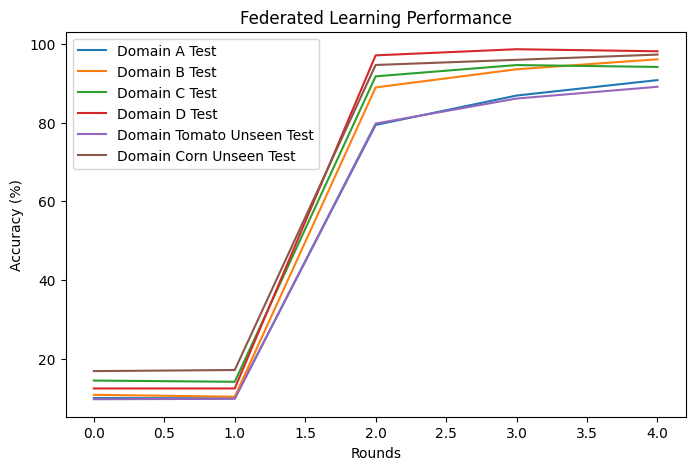

In [ ]:
# ============================================================
# PLOTTING ACCURACY CURVES
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(history_A, label="Domain A Test")
plt.plot(history_B, label="Domain B Test")
plt.plot(history_C, label="Domain C Test")
plt.plot(history_D, label="Domain D Test")
plt.plot(history_tomato_U, label="Domain Tomato Unseen Test")
plt.plot(history_corn_U, label="Domain Corn Unseen Test")


plt.xlabel("Rounds")
plt.ylabel("Accuracy (%)")
plt.title("Federated Learning Performance")
plt.legend()
plt.show()

In [ ]:
import numpy as np
import torch

def get_predictions(model, loader, domain):

    model.to(device)
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            # adjust labels for corn
            if domain == "corn":
                labels = labels - NUM_TOMATO

            # correct head selection
            outputs = model(images, domain=domain)

            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

In [ ]:
# ============================================================
# CONFUSION MATRIX FUNCTION
# ============================================================

from sklearn.metrics import balanced_accuracy_score

def plot_confusion_matrix(model, loader, domain, title):

    y_true, y_pred = get_predictions(model, loader, domain)

    num_classes = NUM_TOMATO if domain == "tomato" else NUM_CORN
    class_names = tomato_labels if domain == "tomato" else corn_labels

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=list(range(num_classes))
    )

    bal_acc = balanced_accuracy_score(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=class_names,
                yticklabels=class_names,
                cmap="Blues")

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.show()

    print("\nBalanced Accuracy:", round(bal_acc * 100, 2), "%")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    return cm, bal_acc

In [ ]:
def class_wise_accuracy(cm, class_names):

    class_acc = {}

    for i, label in enumerate(class_names):
        total = cm[i].sum()
        if total == 0:
            class_acc[label] = 0
        else:
            class_acc[label] = cm[i, i] / total

    return class_acc


CONFUSION MATRIX - Tomato Domains


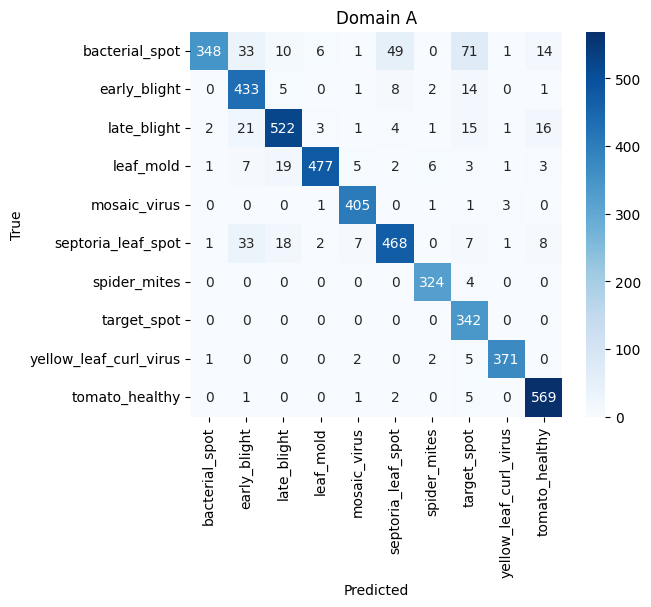


Balanced Accuracy: 91.77 %

Classification Report:
                        precision    recall  f1-score   support

        bacterial_spot       0.99      0.65      0.79       533
          early_blight       0.82      0.93      0.87       464
           late_blight       0.91      0.89      0.90       586
             leaf_mold       0.98      0.91      0.94       524
          mosaic_virus       0.96      0.99      0.97       411
    septoria_leaf_spot       0.88      0.86      0.87       545
          spider_mites       0.96      0.99      0.98       328
           target_spot       0.73      1.00      0.85       342
yellow_leaf_curl_virus       0.98      0.97      0.98       381
        tomato_healthy       0.93      0.98      0.96       578

              accuracy                           0.91      4692
             macro avg       0.91      0.92      0.91      4692
          weighted avg       0.92      0.91      0.91      4692



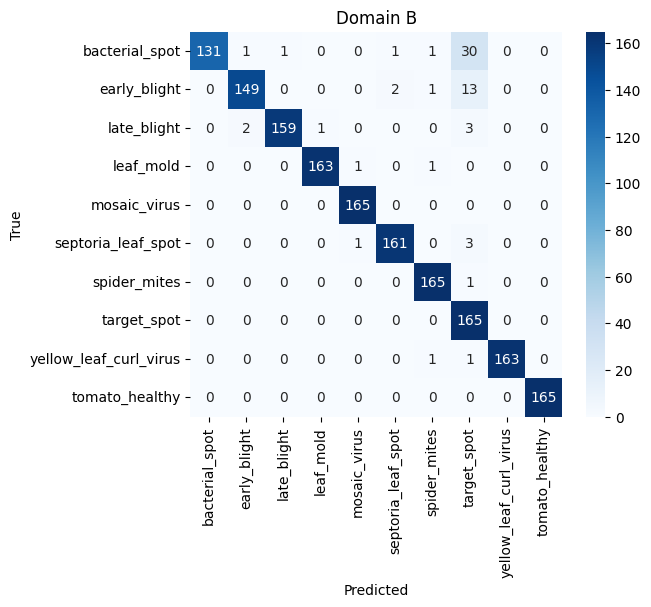


Balanced Accuracy: 96.06 %

Classification Report:
                        precision    recall  f1-score   support

        bacterial_spot       1.00      0.79      0.89       165
          early_blight       0.98      0.90      0.94       165
           late_blight       0.99      0.96      0.98       165
             leaf_mold       0.99      0.99      0.99       165
          mosaic_virus       0.99      1.00      0.99       165
    septoria_leaf_spot       0.98      0.98      0.98       165
          spider_mites       0.98      0.99      0.99       166
           target_spot       0.76      1.00      0.87       165
yellow_leaf_curl_virus       1.00      0.99      0.99       165
        tomato_healthy       1.00      1.00      1.00       165

              accuracy                           0.96      1651
             macro avg       0.97      0.96      0.96      1651
          weighted avg       0.97      0.96      0.96      1651



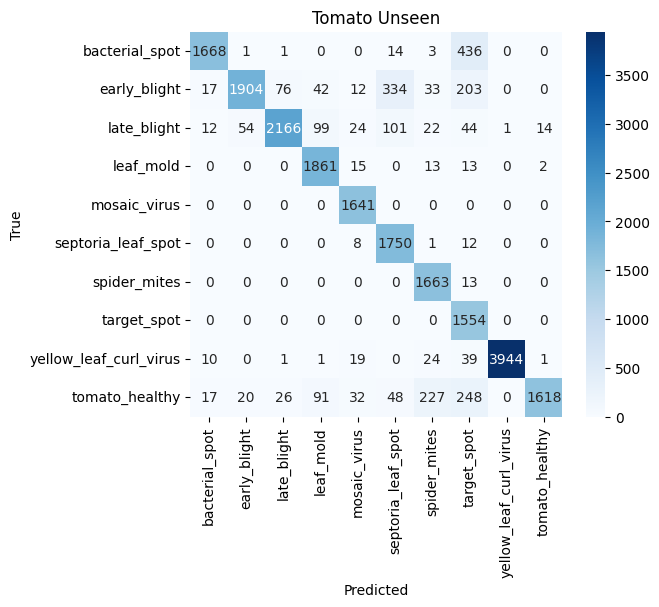


Balanced Accuracy: 89.95 %

Classification Report:
                        precision    recall  f1-score   support

        bacterial_spot       0.97      0.79      0.87      2123
          early_blight       0.96      0.73      0.83      2621
           late_blight       0.95      0.85      0.90      2537
             leaf_mold       0.89      0.98      0.93      1904
          mosaic_virus       0.94      1.00      0.97      1641
    septoria_leaf_spot       0.78      0.99      0.87      1771
          spider_mites       0.84      0.99      0.91      1676
           target_spot       0.61      1.00      0.76      1554
yellow_leaf_curl_virus       1.00      0.98      0.99      4039
        tomato_healthy       0.99      0.70      0.82      2327

              accuracy                           0.89     22193
             macro avg       0.89      0.90      0.88     22193
          weighted avg       0.91      0.89      0.89     22193


Class-wise Accuracy (Domain A):
bacterial_spot: 

In [ ]:
print("\n==============================")
print("CONFUSION MATRIX - Tomato Domains")
print("==============================")

cm_A, bal_A = plot_confusion_matrix(global_model, test_loader_A, "tomato", "Domain A")
cm_B, bal_B = plot_confusion_matrix(global_model, test_loader_B, "tomato", "Domain B")
cm_tomato_U, bal_tomato_U = plot_confusion_matrix(global_model, test_loader_tomato_unseen, "tomato", "Tomato Unseen")

acc_A = class_wise_accuracy(cm_A, tomato_labels)
acc_B = class_wise_accuracy(cm_B, tomato_labels)
acc_tomato_U = class_wise_accuracy(cm_tomato_U, tomato_labels)


print("\nClass-wise Accuracy (Domain A):")
for k, v in acc_A.items():
    print(f"{k}: {v:.4f}")

print("\nClass-wise Accuracy (Domain B):")
for k, v in acc_B.items():
    print(f"{k}: {v:.4f}")

print("\nClass-wise Accuracy (Tomato Unseen Domain):")
for k, v in acc_tomato_U.items():
    print(f"{k}: {v:.4f}")


CONFUSION MATRIX - CORN DOMAINS


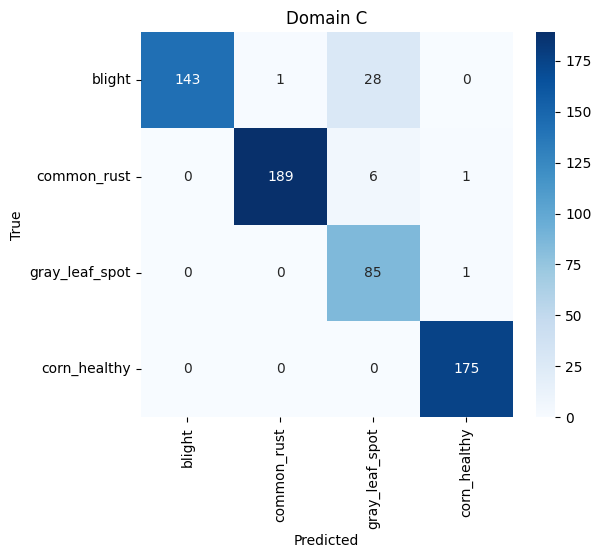


Balanced Accuracy: 94.6 %

Classification Report:
                precision    recall  f1-score   support

        blight       1.00      0.83      0.91       172
   common_rust       0.99      0.96      0.98       196
gray_leaf_spot       0.71      0.99      0.83        86
  corn_healthy       0.99      1.00      0.99       175

      accuracy                           0.94       629
     macro avg       0.92      0.95      0.93       629
  weighted avg       0.96      0.94      0.94       629



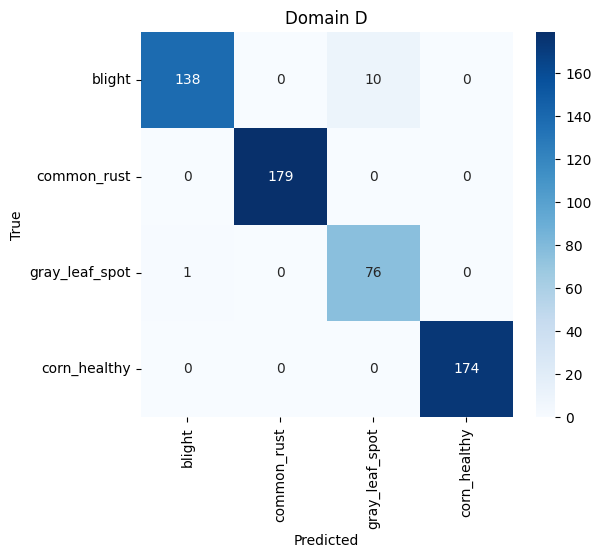


Balanced Accuracy: 97.99 %

Classification Report:
                precision    recall  f1-score   support

        blight       0.99      0.93      0.96       148
   common_rust       1.00      1.00      1.00       179
gray_leaf_spot       0.88      0.99      0.93        77
  corn_healthy       1.00      1.00      1.00       174

      accuracy                           0.98       578
     macro avg       0.97      0.98      0.97       578
  weighted avg       0.98      0.98      0.98       578



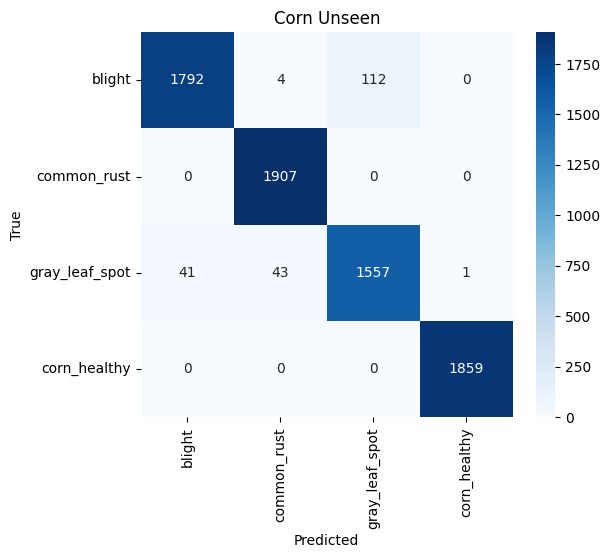


Balanced Accuracy: 97.19 %

Classification Report:
                precision    recall  f1-score   support

        blight       0.98      0.94      0.96      1908
   common_rust       0.98      1.00      0.99      1907
gray_leaf_spot       0.93      0.95      0.94      1642
  corn_healthy       1.00      1.00      1.00      1859

      accuracy                           0.97      7316
     macro avg       0.97      0.97      0.97      7316
  weighted avg       0.97      0.97      0.97      7316


Class-wise Accuracy (Domain C):
blight: 0.8314
common_rust: 0.9643
gray_leaf_spot: 0.9884
corn_healthy: 1.0000

Class-wise Accuracy (Domain D):
blight: 0.9324
common_rust: 1.0000
gray_leaf_spot: 0.9870
corn_healthy: 1.0000

Class-wise Accuracy (Corn Unseen Domain):
blight: 0.9392
common_rust: 1.0000
gray_leaf_spot: 0.9482
corn_healthy: 1.0000


In [ ]:
print("\n==============================")
print("CONFUSION MATRIX - CORN DOMAINS")
print("==============================")

cm_C, bal_C = plot_confusion_matrix(global_model, test_loader_C, "corn", "Domain C")
cm_D, bal_D = plot_confusion_matrix(global_model, test_loader_D, "corn", "Domain D")
cm_corn_U, bal_corn_U = plot_confusion_matrix(global_model, test_loader_corn_unseen, "corn", "Corn Unseen")

acc_C = class_wise_accuracy(cm_C, corn_labels)
acc_D = class_wise_accuracy(cm_D, corn_labels)
acc_corn_U = class_wise_accuracy(cm_corn_U,corn_labels)

print("\nClass-wise Accuracy (Domain C):")
for k, v in acc_C.items():
    print(f"{k}: {v:.4f}")

print("\nClass-wise Accuracy (Domain D):")
for k, v in acc_D.items():
    print(f"{k}: {v:.4f}")

print("\nClass-wise Accuracy (Corn Unseen Domain):")
for k, v in acc_corn_U.items():
    print(f"{k}: {v:.4f}")

In [ ]:
print("\n==============================")
print("BALANCED ACCURACY SUMMARY")
print("==============================")

print(f"Domain A Balanced Accuracy: {bal_A*100:.2f}%")
print(f"Domain B Balanced Accuracy: {bal_B*100:.2f}%")
print(f"Domain C Balanced Accuracy: {bal_C*100:.2f}%")
print(f"Domain D Balanced Accuracy: {bal_D*100:.2f}%")
print(f"Tomato Unseen Domain Balanced Accuracy: {bal_tomato_U*100:.2f}%")
print(f"Corn Unseen Domain Balanced Accuracy: {bal_corn_U*100:.2f}%")


BALANCED ACCURACY SUMMARY
Domain A Balanced Accuracy: 91.77%
Domain B Balanced Accuracy: 96.06%
Domain C Balanced Accuracy: 94.60%
Domain D Balanced Accuracy: 97.99%
Tomato Unseen Domain Balanced Accuracy: 89.95%
Corn Unseen Domain Balanced Accuracy: 97.19%
